# EDA on Retail Sales Data
**Track:** Data Analytics (Level 1, Task 1)

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** `retail_sales.csv` — 3,000 synthetic retail transactions spanning Jan 2022–Jun 2024, across 7 product categories, 5 regions, and customer demographic segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('retail_sales.csv', parse_dates=['OrderDate'])
print('Shape:', df.shape)
df.head()

Shape: (3000, 9)


   OrderDate   Region AgeGroup  Gender    Category      Product  Quantity  \
0 2022-01-01  Central    46-55  Female  Home Decor  Cushion Set         2   
1 2022-01-01    North    46-55    Male      Sports  Cricket Bat         4   
2 2022-01-01    South    26-35  Female    Clothing        Jeans         3   
3 2022-01-01  Central    46-55  Female  Home Decor  Cushion Set         4   
4 2022-01-02    North    36-45    Male    Clothing     Sneakers         1   

   UnitPrice  Revenue  
0    1090.88  1963.58  
1    1313.86  4729.89  
2     894.73  2415.78  
3     890.51  3205.84  
4     928.22   835.39  

## 1. Initial Inspection

In [2]:
print('--- Dtypes ---')
print(df.dtypes)
print()
print('--- Null values ---')
print(df.isnull().sum())
print()
print('--- Date range ---')
print(df['OrderDate'].min(), 'to', df['OrderDate'].max())

--- Dtypes ---
OrderDate    datetime64[us]
Region                  str
AgeGroup                str
Gender                  str
Category                str
Product                 str
Quantity              int64
UnitPrice           float64
Revenue             float64
dtype: object

--- Null values ---
OrderDate    0
Region       0
AgeGroup     0
Gender       0
Category     0
Product      0
Quantity     0
UnitPrice    0
Revenue      0
dtype: int64

--- Date range ---
2022-01-01 00:00:00 to 2024-06-30 00:00:00


## 2. Descriptive Statistics

In [3]:
df[['Quantity','UnitPrice','Revenue']].describe()

          Quantity    UnitPrice       Revenue
count  3000.000000  3000.000000   3000.000000
mean      3.057333  1091.126120   3482.412483
std       1.430872   687.653328   3028.751571
min       1.000000   121.210000    155.380000
25%       2.000000   502.197500   1330.205000
50%       3.000000   926.500000   2420.715000
75%       4.000000  1525.142500   4810.157500
max       5.000000  3354.610000  20467.760000

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

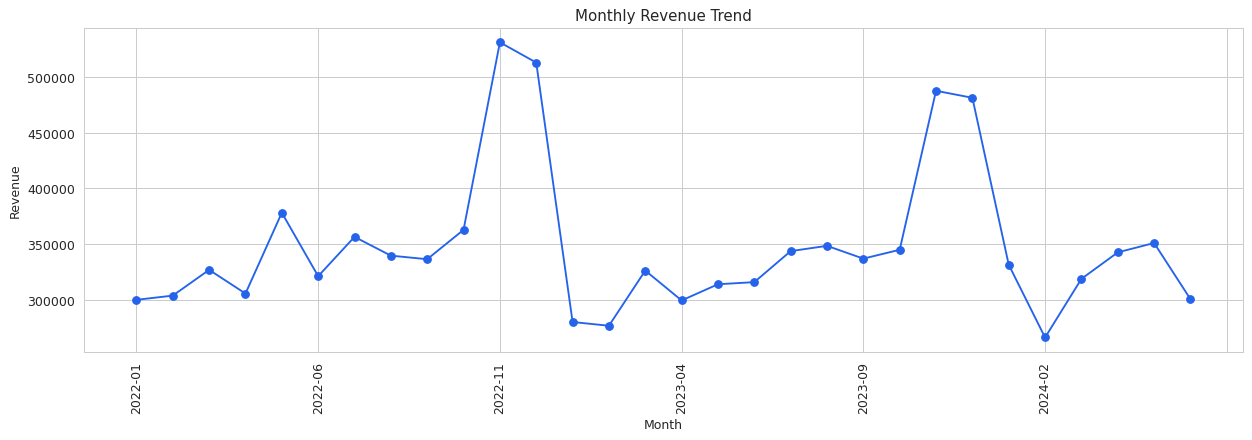

In [4]:
df['YearMonth'] = df['OrderDate'].dt.to_period('M').astype(str)
df['YearQuarter'] = df['OrderDate'].dt.to_period('Q').astype(str)

monthly = df.groupby('YearMonth')['Revenue'].sum()
fig, ax = plt.subplots(figsize=(14,5))
monthly.plot(ax=ax, marker='o', color='#2563eb')
ax.set_title('Monthly Revenue Trend')
ax.set_ylabel('Revenue')
ax.set_xlabel('Month')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=100)
plt.show()

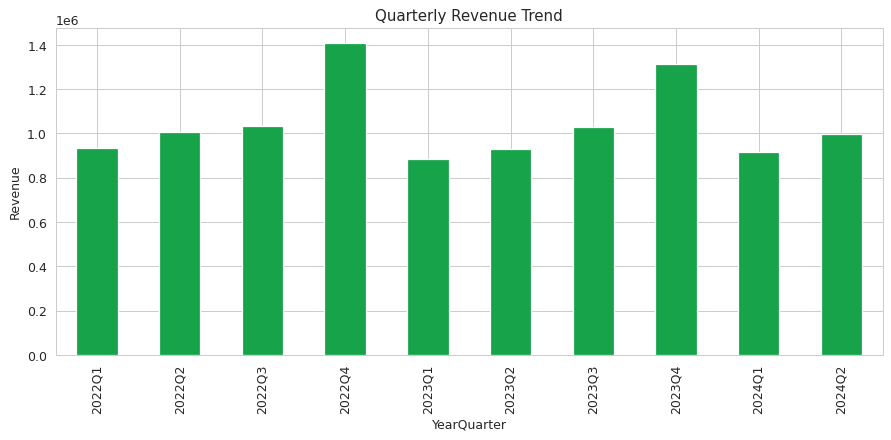

In [5]:
quarterly = df.groupby('YearQuarter')['Revenue'].sum()
fig, ax = plt.subplots(figsize=(10,5))
quarterly.plot(kind='bar', ax=ax, color='#16a34a')
ax.set_title('Quarterly Revenue Trend')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig('quarterly_revenue_trend.png', dpi=100)
plt.show()

**Observation:** Revenue shows a clear seasonal spike in Nov–Dec each year (holiday shopping effect built into the data), with a dip in Jan–Feb. Quarterly revenue trends upward year over year, suggesting overall business growth alongside the seasonal cycle.

## 4. Customer Demographics Analysis

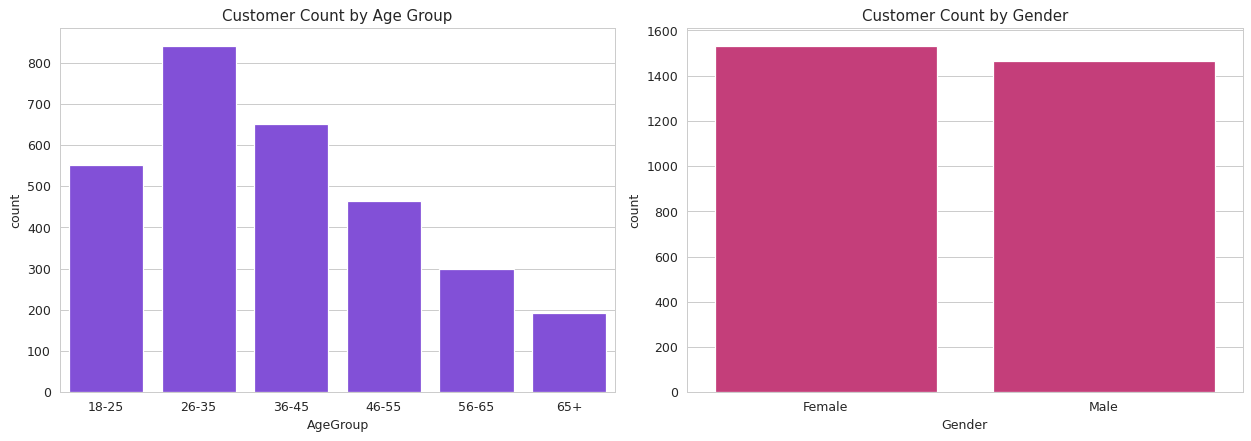

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
age_order = ['18-25','26-35','36-45','46-55','56-65','65+']
sns.countplot(data=df, x='AgeGroup', order=age_order, ax=axes[0], color='#7c3aed')
axes[0].set_title('Customer Count by Age Group')
sns.countplot(data=df, x='Gender', ax=axes[1], color='#db2777')
axes[1].set_title('Customer Count by Gender')
plt.tight_layout()
plt.savefig('demographics.png', dpi=100)
plt.show()

**Observation:** The 26-35 age group makes up the largest share of customers, followed by 36-45. Gender split is close to even, with a slight lean toward one group depending on category (explored further below).

## 5. Product Analysis — Top Products & Revenue by Category

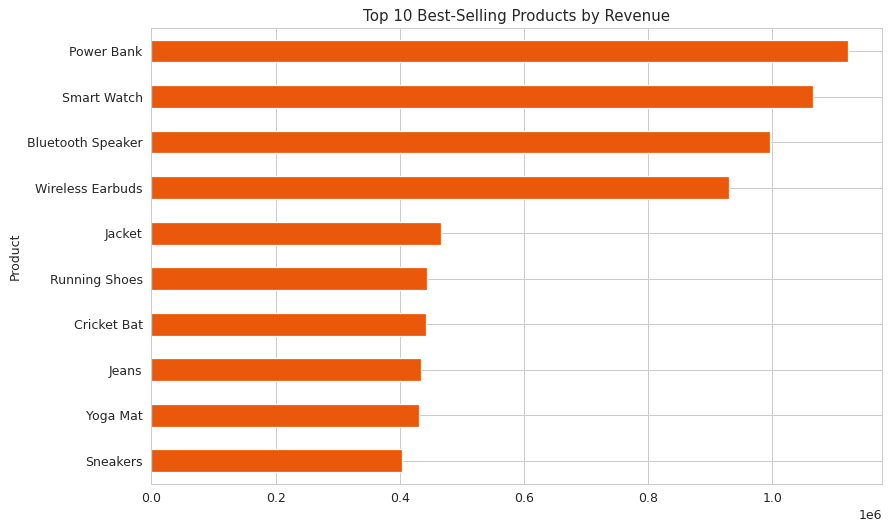

In [7]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,6))
top_products.plot(kind='barh', ax=ax, color='#ea580c')
ax.set_title('Top 10 Best-Selling Products by Revenue')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_products.png', dpi=100)
plt.show()

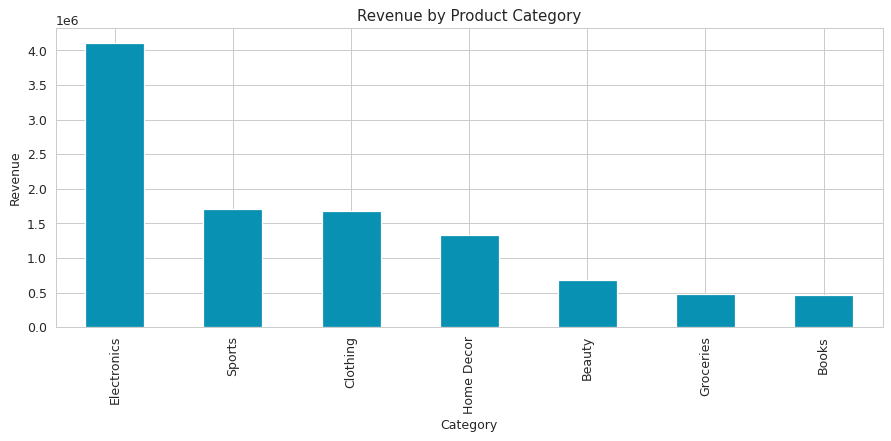

Category
Electronics    4112347.79
Sports         1709154.74
Clothing       1673840.40
Home Decor     1335428.19
Beauty          676582.00
Groceries       474930.54
Books           464953.79
Name: Revenue, dtype: float64

In [8]:
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,5))
category_revenue.plot(kind='bar', ax=ax, color='#0891b2')
ax.set_title('Revenue by Product Category')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig('category_revenue.png', dpi=100)
plt.show()
category_revenue

## 6. Correlation Heatmap

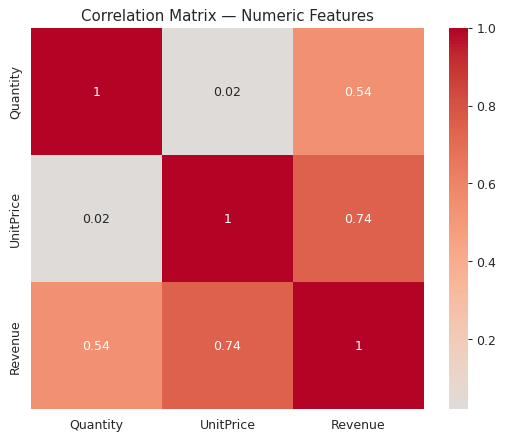

In [9]:
numeric_cols = df[['Quantity','UnitPrice','Revenue']]
corr = numeric_cols.corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()

## 7. Additional Insight — Revenue by Region and Category (non-obvious pattern)

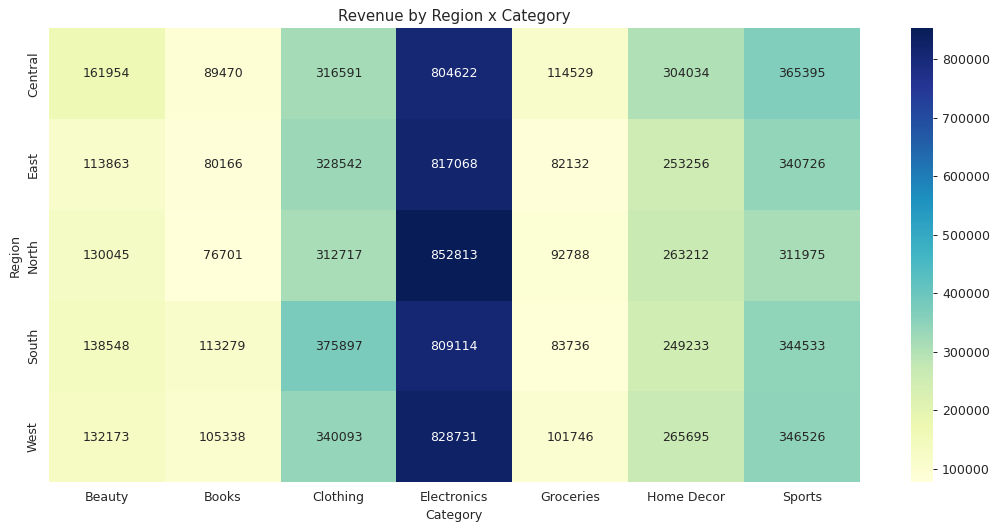

In [10]:
pivot = df.pivot_table(index='Region', columns='Category', values='Revenue', aggfunc='sum')
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title('Revenue by Region x Category')
plt.tight_layout()
plt.savefig('region_category_heatmap.png', dpi=100)
plt.show()

**Observation:** Certain regions over-index on specific categories rather than spending evenly across all of them — this points to opportunities for region-specific merchandising and localized promotions rather than a one-size-fits-all catalog strategy.

## 8. Conclusion — Business Recommendations

Based on the analysis above:

1. **Plan inventory and staffing around the Nov–Dec seasonal peak.** Revenue consistently spikes in these months — stock up on top categories ahead of time and consider early-bird holiday promotions to capture demand before competitors.
2. **Double down on marketing to the 26-45 age bracket**, which drives the largest share of transactions, while running targeted acquisition campaigns for underrepresented groups (56+) where there's room to grow.
3. **Use region-specific merchandising.** Since categories don't sell evenly across all regions, tailor promotions and stock allocation per region instead of applying a uniform national strategy — this should improve both sell-through rates and margins.